# MTPL2 Frequency Modelling Walkthrough

End-to-end Poisson frequency model on the French MTPL2 dataset (678k
policies). Covers data prep, model fitting, relativity inspection,
and the impact of discretising smooth curves into rating tables.

Sections:

1. **Data loading & preparation**
2. **Model specification** — splines, categoricals, numerics
3. **Fitting with REML** — automatic smoothness selection
4. **Relativity plots** — grid, individual terms, layout options
5. **Summary table** — statsmodels-style output
6. **Discretisation impact** — binning smooth curves into rating tables
7. **Rating tables** — per-feature step functions for deployment

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from superglm import Categorical, Numeric, Poisson, Spline, SuperGLM

## 1. Data loading & preparation

The French MTPL2 frequency dataset contains 678k motor third-party
liability policies with claim counts and exposure. We fetch it from
OpenML (no local files needed) and apply standard actuarial cleaning.

In [2]:
from sklearn.datasets import fetch_openml

df = fetch_openml(data_id=41214, as_frame=True, parser="auto").frame

# Standard cleaning
df["ClaimNb"] = df["ClaimNb"].astype(float).clip(upper=4)
df["Exposure"] = df["Exposure"].astype(float).clip(lower=0.01)
df["DrivAge"] = df["DrivAge"].astype(float).clip(18, 90)
df["VehAge"] = df["VehAge"].astype(float).clip(0, 20)
df["BonusMalus"] = df["BonusMalus"].astype(float).clip(50, 150)
df["Density"] = df["Density"].astype(float)
df["LogDensity"] = np.log1p(df["Density"])

y = df["ClaimNb"].values
exposure = df["Exposure"].values

features_to_use = ["DrivAge", "VehAge", "BonusMalus", "LogDensity", "Area", "VehGas"]
X = df[features_to_use]

print(f"Rows: {len(df):,}")
print(f"Claim rate: {y.sum() / exposure.sum():.4f}")
print(f"Zero fraction: {(y == 0).mean():.1%}")
X.describe().round(2)

Rows: 678,013
Claim rate: 0.1006
Zero fraction: 95.0%


,DrivAge,VehAge,BonusMalus,LogDensity
count,678013.00,678013.00,678013.00,678013.00
mean,45.50,6.98,59.76,5.99
std,14.13,5.40,15.61,1.86
min,18.00,0.00,50.00,0.69
25%,34.00,2.00,50.00,4.53
50%,44.00,6.00,50.00,5.98
75%,55.00,11.00,64.00,7.41
max,90.00,20.00,150.00,10.20


## 2. Model specification

A typical actuarial frequency model mixes feature types:

| Feature | Type | Why |
|---------|------|-----|
| DrivAge | `Spline(kind="bs", n_knots=15)` | Smooth U-shaped effect |
| VehAge | `Spline(kind="bs", n_knots=10)` | Smooth decreasing effect |
| BonusMalus | `Spline(kind="bs", n_knots=8)` | Strongly monotone, needs flexibility |
| LogDensity | `Numeric()` | Log-linear in population density |
| Area | `Categorical()` | 6 unordered regions |
| VehGas | `Categorical()` | Diesel vs Regular |

In [3]:
model = SuperGLM(
    family=Poisson(),
    discrete=True,
    features={
        "DrivAge": Spline(kind="cr", n_knots=15, knot_strategy="quantile_rows", penalty="ssp"),
        "VehAge": Spline(kind="cr", n_knots=10, knot_strategy="uniform", penalty="ssp"),
        "BonusMalus": Spline(
            kind="cr", n_knots=8, knot_strategy="quantile_tempered", knot_alpha=0.2, penalty="ssp"
        ),
        "LogDensity": Numeric(),
        "Area": Categorical(base="most_exposed"),
        "VehGas": Categorical(base="most_exposed"),
    },
)
print("Model specified.")

Model specified.


## 3. Fitting with REML

`fit_reml()` estimates smoothing parameters automatically via
restricted marginal likelihood (Wood 2011). No manual tuning of
lambda needed — REML finds the right amount of smoothing for
each spline.

In [4]:
t0 = time.perf_counter()
model.fit_reml(X, y, exposure=exposure)
elapsed = time.perf_counter() - t0

print(f"Fit time: {elapsed:.1f}s")
print(f"REML converged: {model._reml_result.converged}")
print(f"REML iterations: {model._reml_result.n_reml_iter}")
print("\nPer-feature edf:")
for name in model._feature_order:
    ti = model.term_inference(name, with_se=False)
    edf_str = f"{ti.edf:.1f}" if ti.edf is not None else "—"
    print(f"  {name:15s} edf = {edf_str}")

Fit time: 9.7s
REML converged: True
REML iterations: 5

Per-feature edf:


  DrivAge         edf = 11.5
  VehAge          edf = 10.3
  BonusMalus      edf = 8.8
  LogDensity      edf = 1.0
  Area            edf = 5.0
  VehGas          edf = 1.0


## 4. Relativity plots

### 4a. All features in a grid

The default `model.plot()` shows all main effects in a 2-column grid
with exposure density overlays and pointwise CIs.

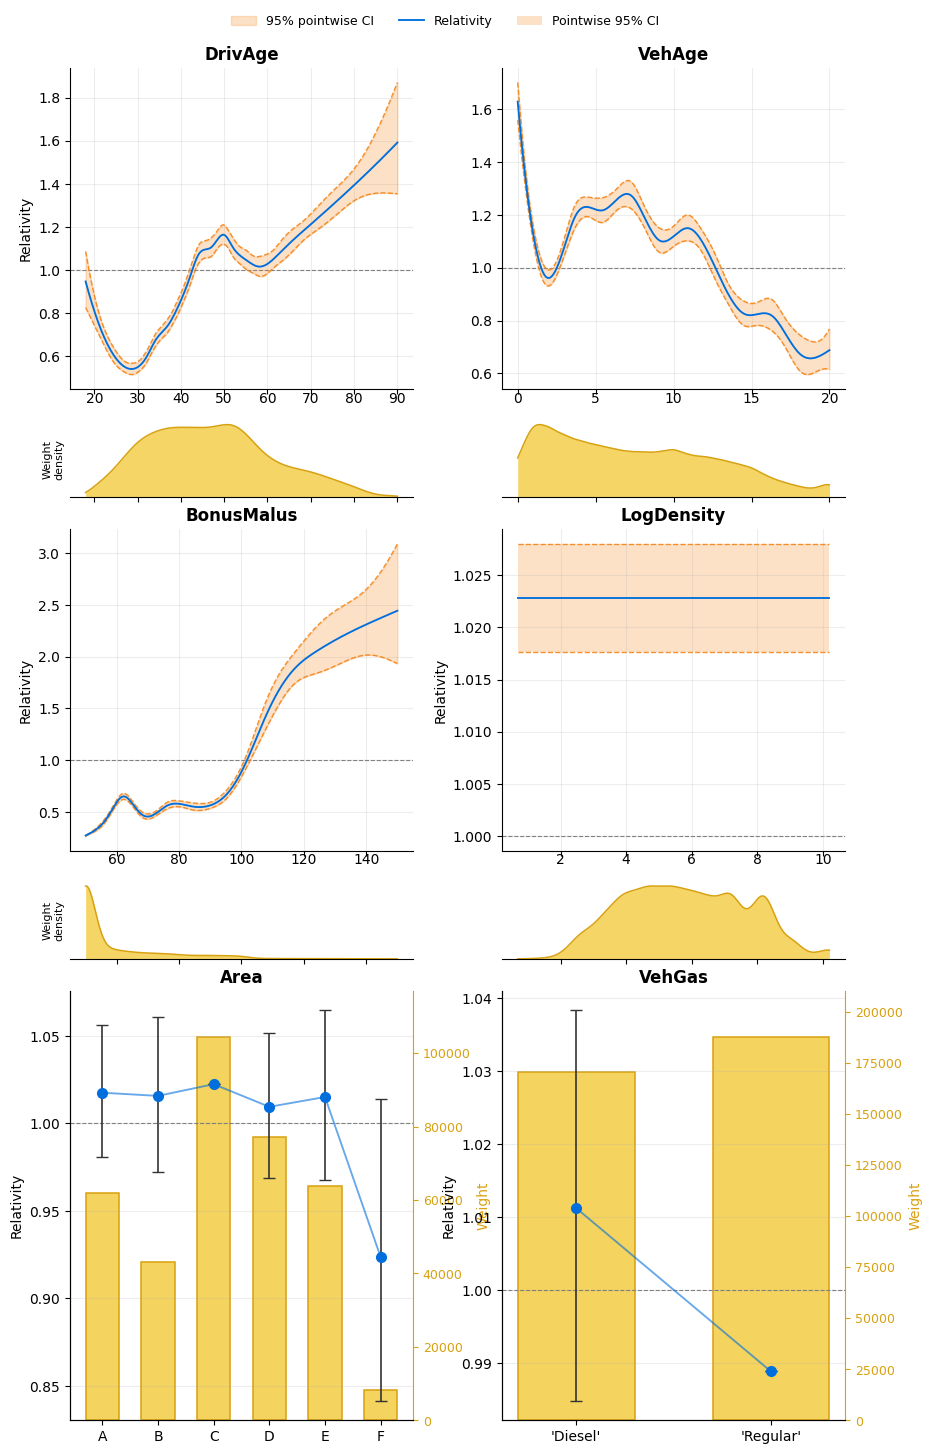

In [5]:
fig = model.plot(X=X, sample_weight=exposure)
plt.show()

### 4b. Single term — large format

Plot one term at a time for detailed inspection. Useful for
presentations or reports where you want to focus on one effect.

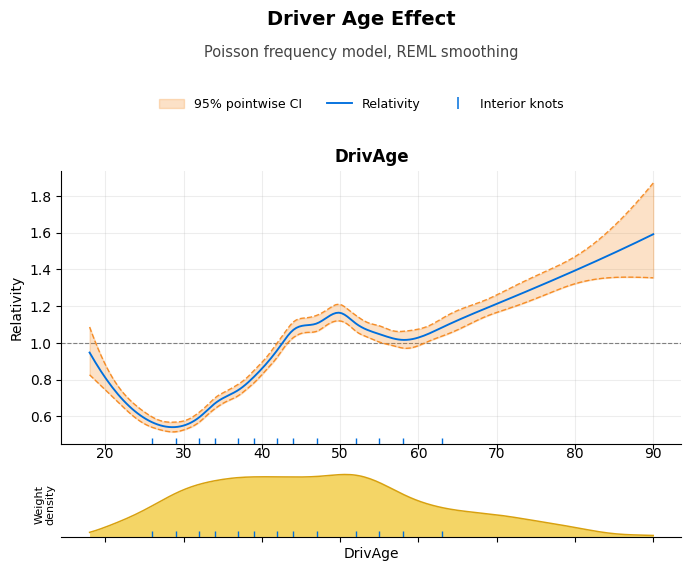

In [6]:
fig = model.plot(
    "DrivAge",
    X=X,
    sample_weight=exposure,
    show_knots=True,
    figsize=(8, 6),
    title="Driver Age Effect",
    subtitle="Poisson frequency model, REML smoothing",
)
plt.show()

### 4c. Subset of terms

Pass a list of feature names to plot a subset in a grid.

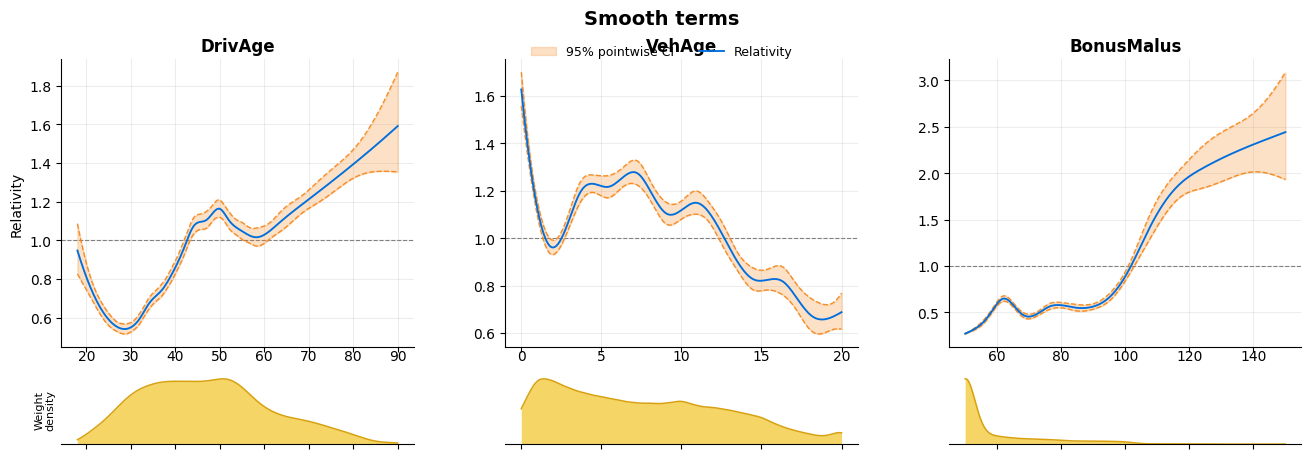

In [7]:
fig = model.plot(
    ["DrivAge", "VehAge", "BonusMalus"],
    X=X,
    sample_weight=exposure,
    ncols=3,
    figsize=(16, 5),
    title="Smooth terms",
)
plt.show()

### 4d. Simultaneous confidence bands

Pointwise CIs are narrow but don't account for multiple testing across
the curve. Simultaneous bands (Wood 2006, posterior simulation) give
honest coverage for the entire curve.

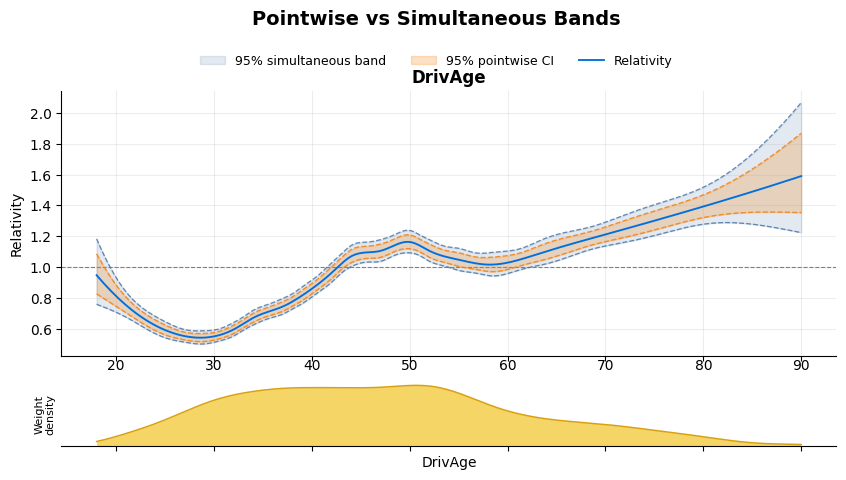

In [8]:
fig = model.plot(
    "DrivAge",
    ci="both",
    X=X,
    sample_weight=exposure,
    figsize=(10, 5),
    title="Pointwise vs Simultaneous Bands",
)
plt.show()

## 5. Summary table

statsmodels-style summary with coefficient estimates, smooth term
edf, and Wood (2013) p-values for smooth terms.

In [9]:
model.summary()

╔═════════════════════════════ SuperGLM Results ═════════════════════════════╗
║ Family:                      Poisson  No. Observations:             678013 ║
║ Link:                            Log  Df (effective):                38.65 ║
║ Method:               REML, discrete  Penalty:                 Group Lasso ║
║ Scale (phi):                   1.000  Lambda1:                      0.0284 ║
║ Log-Likelihood:             -85239.6  AIC:                        170556.5 ║
║ AICc:                       170556.5  BIC:                        170998.1 ║
║ EBIC:                       170998.1  Converged:             True (2 iter) ║
║ Deviance:                   125942.7                                       ║
╠════════════════════════════════════════════════════════════════════════════╣
║                       coef   std err     z     P>|z|   [0.025   0.975]     ║
╟────────────────────────────────────────────────────────────────────────────╢
║ Intercept          -2.9192    0.0066  -444.4   0.000   -2.932   -2.906 *** ║
║                                                                            ║
╠════════════════════════════════╡ DrivAge ╞═════════════════════════════════╣
║                                                                            ║
║ DrivAge           [spline, 16 params, chi2(13.2)=1237.4, p=<0.001]     *** ║
║                     rank=16, edf=11.5, lam=1.8e+03, curve SE: 0.02-0.08    ║
║                                                                            ║
╠═════════════════════════════════╡ VehAge ╞═════════════════════════════════╣
║                                                                            ║
║ VehAge            [spline, 11 params, chi2(10.9)=710.9, p=<0.001]      *** ║
║                     rank=11, edf=10.3, lam=35, curve SE: 0.01-0.06         ║
║                                                                            ║
╠═══════════════════════════════╡ BonusMalus ╞═══════════════════════════════╣
║                                                                            ║
║ BonusMalus        [spline, 9 params, chi2(9.0)=3938.0, p=<0.001]       *** ║
║                     rank=9, edf=8.8, lam=9.1e+02, curve SE: 0.01-0.12      ║
║                                                                            ║
╠═══════════════════════════════╡ LogDensity ╞═══════════════════════════════╣
║                                                                            ║
║ LogDensity          0.0226    0.0026   8.711   0.000    0.017    0.028 *** ║
║                                                                            ║
╠══════════════════════════════════╡ Area ╞══════════════════════════════════╣
║                                                                            ║
║ Area[A]            -0.0048    0.0189  -0.253   0.800   -0.042    0.032     ║
║ Area[B]            -0.0066    0.0222  -0.297   0.767   -0.050    0.037     ║
║ Area[D]            -0.0127    0.0210  -0.606   0.544   -0.054    0.028     ║
║ Area[E]            -0.0072    0.0243  -0.296   0.767   -0.055    0.040     ║
║ Area[F]            -0.1016    0.0475  -2.140   0.032   -0.195   -0.009 *   ║
║                                                                            ║
╠═════════════════════════════════╡ VehGas ╞═════════════════════════════════╣
║                                                                            ║
║ VehGas['Diesel']    0.0224    0.0135   1.659   0.097   -0.004    0.049 .   ║
╚════════════════════════════════════════════════════════════════════════════╝
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Note: smooth p-values use Wood (2013) Bayesian test.
Parametric p-values are Wald approximations.
For borderline significance, use a likelihood ratio test.

## 6. Discretisation impact

In production, smooth spline curves are typically discretised into
step-function rating tables (e.g. 10–20 age bands). The question is:
how many bins do you need before the approximation stops mattering?

`discretization_impact()` replaces each smooth per-observation
log-relativity with an exposure-weighted bin average, recomputes
predictions, and reports how much the deviance and predictions shift.

In [10]:
# Compare bin counts: how many bins before the error is negligible?
for n_bins in [5, 10, 20, 50, 100]:
    r = model.discretization_impact(X, y, exposure=exposure, n_bins=n_bins)
    m = r.metrics
    print(
        f"  {n_bins:3d} bins: "
        f"deviance change {m['deviance_change_pct']:+.4f}%, "
        f"mean pred change {m['mean_abs_prediction_change_pct']:.4f}%, "
        f"corr {m['prediction_correlation']:.6f}"
    )

    5 bins: deviance change +2.2951%, mean pred change 18.5617%, corr 0.618703


   10 bins: deviance change +0.9063%, mean pred change 10.2517%, corr 0.795613


   20 bins: deviance change +0.5816%, mean pred change 6.2053%, corr 0.852473


   50 bins: deviance change +0.2947%, mean pred change 2.5062%, corr 0.927109


  100 bins: deviance change +0.2217%, mean pred change 1.6795%, corr 0.928528


## 7. Rating tables

With a practical bin count chosen, extract the per-feature rating
tables and overlay the step function on the smooth curve.

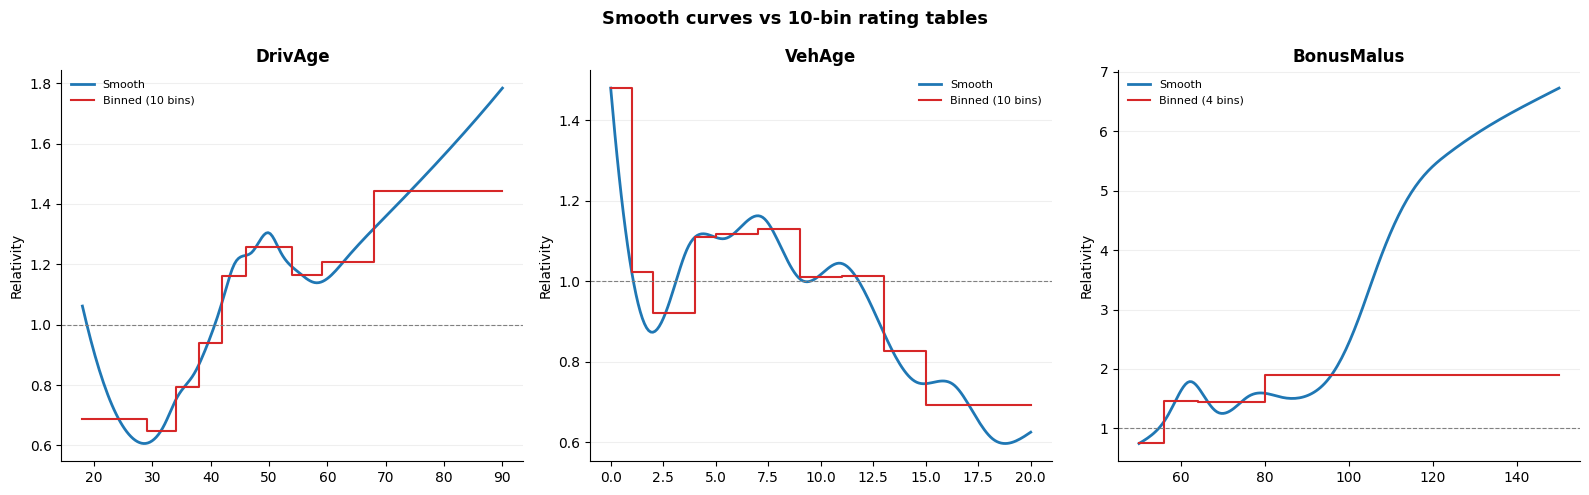

In [11]:
result = model.discretization_impact(X, y, exposure=exposure, n_bins=10)

spline_names = ["DrivAge", "VehAge", "BonusMalus"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, spline_names):
    # Smooth curve on native scale (no mean centering) to match rating table
    ti = model.term_inference(name, centering="native")
    ax.plot(ti.x, ti.relativity, color="#1f77b4", linewidth=2, label="Smooth")

    # Step function from rating table
    table = result.tables[name]
    step_x, step_y = [], []
    for _, row in table.iterrows():
        step_x.extend([row["bin_from"], row["bin_to"]])
        step_y.extend([row["relativity"], row["relativity"]])
    ax.plot(step_x, step_y, color="#d62728", linewidth=1.5, label=f"Binned ({len(table)} bins)")

    ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Relativity")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Smooth curves vs 10-bin rating tables", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

In [12]:
# Inspect one rating table
print("DrivAge rating table (10 bins, exposure-quantile):\n")
result.tables["DrivAge"]

DrivAge rating table (10 bins, exposure-quantile):



,bin_from,bin_to,relativity,log_relativity,n_obs,exposure
0,18.0,29.0,0.686483,-0.376174,74459,31750.76
1,29.0,34.0,0.648001,-0.433864,79627,37087.75
2,34.0,38.0,0.793257,-0.231609,68817,34175.61
3,38.0,42.0,0.938921,-0.063024,68660,35190.95
4,42.0,46.0,1.159659,0.148126,66867,35012.46
5,46.0,50.0,1.257141,0.228840,64841,35124.43
6,50.0,54.0,1.257771,0.229341,66993,37270.55
7,54.0,59.0,1.163710,0.151613,66019,37209.91
8,59.0,68.0,1.207409,0.188477,66583,38708.73
9,68.0,90.0,1.444211,0.367563,55147,37003.08


## 8. Key takeaways

| | Detail |
|---|---|
| **REML** | Automatic smoothness — no manual lambda tuning |
| **Discretisation** | 10–20 bins per feature is enough for < 0.01% deviance change |
| **Rating tables** | `discretization_impact()` gives deployment-ready step functions |
| **Workflow** | Fit smooth → inspect curves → discretise for production |

The smooth model is the statistical model. The rating table is
what goes into the pricing engine. `discretization_impact()` bridges
the two and quantifies the approximation error.